In [1]:
import torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
import numpy as np, random
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

# ---------- reproducibility & device ----------
seed = 42
random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
# ---------- hyperparams ----------
batch_size = 128
dae_epochs = 30
clf_epochs = 12
dae_lr = 1e-3
clf_lr = 1e-3
noise_factor = 0.25
hidden1 = 256
bottleneck = 64

# ---------- data ----------
transform = transforms.Compose([transforms.ToTensor()])
train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
val_ds   = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
print(f"Train size: {len(train_ds)}  Val size: {len(val_ds)}")

Train size: 60000  Val size: 10000


In [3]:
# ---------- noise helper ----------
def add_noise(x, noise_factor=noise_factor):
    noisy = x + noise_factor * torch.randn_like(x)
    return torch.clamp(noisy, 0.0, 1.0)

# ---------- model ----------
class DenoisingAutoencoder(nn.Module):
    def __init__(self, input_dim=28*28, hidden1=256, bottleneck=64):
        super().__init__()
        self.enc_fc1 = nn.Linear(input_dim, hidden1)
        self.enc_fc2 = nn.Linear(hidden1, bottleneck)
        self.dec_fc1 = nn.Linear(bottleneck, hidden1)
        self.dec_fc2 = nn.Linear(hidden1, input_dim)
    def encode(self, x):
        x = x.view(x.size(0), -1)
        h = F.relu(self.enc_fc1(x))
        z = F.relu(self.enc_fc2(h))
        return z
    def decode(self, z):
        h = F.relu(self.dec_fc1(z))
        x_hat = torch.sigmoid(self.dec_fc2(h))
        return x_hat
    def forward(self, x_noisy):
        z = self.encode(x_noisy)
        x_hat = self.decode(z)
        return x_hat, z

# ---------- instantiate ----------
dae = DenoisingAutoencoder(input_dim=28*28, hidden1=hidden1, bottleneck=bottleneck).to(device)
opt = optim.Adam(dae.parameters(), lr=dae_lr, weight_decay=1e-5)

# ---------- train / eval loops ----------
def dae_train_one_epoch(model, opt, loader, device, noise_factor):
    model.train()
    running_recon = 0.0
    total = 0
    for xb, _ in loader:
        xb = xb.to(device)
        xb_noisy = add_noise(xb, noise_factor)
        x_hat, _ = model(xb_noisy)
        recon = F.mse_loss(x_hat, xb.view(xb.size(0), -1), reduction='mean')
        opt.zero_grad(); recon.backward(); opt.step()
        bs = xb.size(0)
        running_recon += float(recon.item()) * bs
        total += bs
    return running_recon / total

def dae_evaluate(model, loader, device, noise_factor):
    model.eval()
    running_recon = 0.0
    total = 0
    with torch.no_grad():
        for xb, _ in loader:
            xb = xb.to(device)
            xb_noisy = add_noise(xb, noise_factor)
            x_hat, _ = model(xb_noisy)
            recon = F.mse_loss(x_hat, xb.view(xb.size(0), -1), reduction='mean')
            bs = xb.size(0)
            running_recon += float(recon.item()) * bs
            total += bs
    return running_recon / total


In [4]:
# ---------- training ----------
history = {"train_recon": [], "val_recon": []}
best_val = float('inf')
start = datetime.now()
for ep in range(1, dae_epochs + 1):
    tr = dae_train_one_epoch(dae, opt, train_loader, device, noise_factor)
    val = dae_evaluate(dae, val_loader, device, noise_factor)
    history["train_recon"].append(tr); history["val_recon"].append(val)
    if val < best_val:
        best_val = val
        torch.save({"dae_state_dict": dae.state_dict(), "epoch": ep, "history": history}, Path("denoising_ae_best.pth"))
    if ep % 5 == 0 or ep == 1 or ep == dae_epochs:
        print(f"DAE ep {ep}/{dae_epochs} train_recon={tr:.6f} val_recon={val:.6f}")
end = datetime.now()
print("DAE training finished — elapsed:", end - start)
print("Saved denoising_ae_best.pth")

# ---------- extract bottleneck features (encode clean images) ----------
def extract_feats(ae, loader, device):
    ae.eval()
    feats = []; labels = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            z = ae.encode(xb)
            feats.append(z.cpu()); labels.append(yb)
    feats = torch.cat(feats, dim=0); labels = torch.cat(labels, dim=0)
    return feats, labels

train_feats, train_labels = extract_feats(dae, train_loader, device)
val_feats, val_labels = extract_feats(dae, val_loader, device)
print("Train feats:", train_feats.shape, "Val feats:", val_feats.shape)

DAE ep 1/30 train_recon=0.047072 val_recon=0.027293
DAE ep 5/30 train_recon=0.014895 val_recon=0.014068
DAE ep 10/30 train_recon=0.011905 val_recon=0.011440
DAE ep 15/30 train_recon=0.010914 val_recon=0.010665
DAE ep 20/30 train_recon=0.010402 val_recon=0.010038
DAE ep 25/30 train_recon=0.010047 val_recon=0.009807
DAE ep 30/30 train_recon=0.009841 val_recon=0.009576
DAE training finished — elapsed: 0:04:01.907857
Saved denoising_ae_best.pth
Train feats: torch.Size([60000, 64]) Val feats: torch.Size([10000, 64])


In [5]:
# ---------- classifier on features ----------
class FeatureClassifier(nn.Module):
    def __init__(self, input_dim, hidden=128, num_classes=10):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden)
        self.fc2 = nn.Linear(hidden, num_classes)
    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)

clf = FeatureClassifier(input_dim=train_feats.shape[1], hidden=128).to(device)
clf_opt = optim.Adam(clf.parameters(), lr=clf_lr)
clf_crit = nn.CrossEntropyLoss()

train_ds_feat = TensorDataset(train_feats, train_labels)
val_ds_feat = TensorDataset(val_feats, val_labels)
train_loader_feat = DataLoader(train_ds_feat, batch_size=256, shuffle=True)
val_loader_feat = DataLoader(val_ds_feat, batch_size=256, shuffle=False)

clf_hist = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}
best_val_acc = 0.0
for ep in range(1, clf_epochs+1):
    # train
    clf.train()
    running_loss = 0; correct = 0; total = 0
    for xb, yb in train_loader_feat:
        xb, yb = xb.to(device), yb.to(device)
        logits = clf(xb)
        loss = clf_crit(logits, yb)
        clf_opt.zero_grad(); loss.backward(); clf_opt.step()
        running_loss += float(loss.item()) * xb.size(0)
        preds = logits.argmax(dim=1); correct += (preds == yb).sum().item()
        total += xb.size(0)
    train_loss = running_loss/total; train_acc = correct/total

    # val
    clf.eval()
    running_loss = 0; correct = 0; total = 0
    with torch.no_grad():
        for xb, yb in val_loader_feat:
            xb, yb = xb.to(device), yb.to(device)
            logits = clf(xb)
            loss = clf_crit(logits, yb)
            running_loss += float(loss.item()) * xb.size(0)
            preds = logits.argmax(dim=1); correct += (preds == yb).sum().item()
            total += xb.size(0)
    val_loss = running_loss/total; val_acc = correct/total
    clf_hist["train_loss"].append(train_loss); clf_hist["val_loss"].append(val_loss)
    clf_hist["train_acc"].append(train_acc); clf_hist["val_acc"].append(val_acc)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({"clf_state": clf.state_dict(), "epoch": ep, "hist": clf_hist}, Path("dae_feature_clf_best.pth"))
    if ep % 3 == 0 or ep == 1 or ep == clf_epochs:
        print(f"CLF ep {ep}/{clf_epochs} train_acc={train_acc*100:.2f}% val_acc={val_acc*100:.2f}%")

print("Classifier finished — best val acc: {:.2f}%".format(best_val_acc*100))


CLF ep 1/12 train_acc=82.64% val_acc=91.23%
CLF ep 3/12 train_acc=93.37% val_acc=94.32%
CLF ep 6/12 train_acc=95.64% val_acc=96.13%
CLF ep 9/12 train_acc=96.59% val_acc=96.64%
CLF ep 12/12 train_acc=97.02% val_acc=96.70%
Classifier finished — best val acc: 96.70%


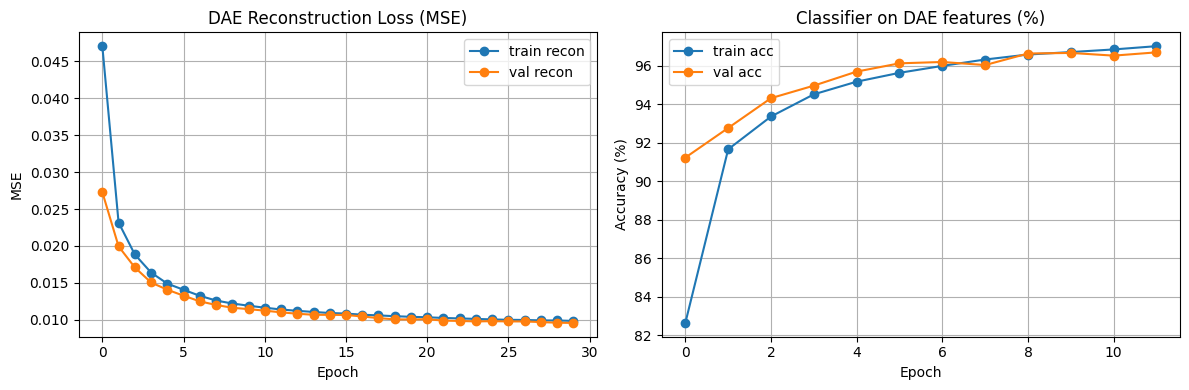

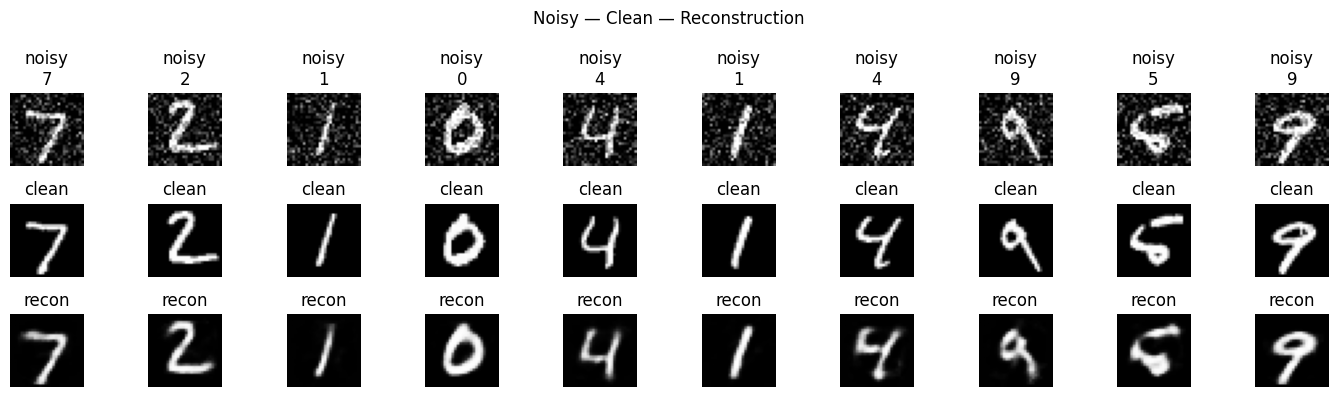

DAE bottleneck dim: 64
Classifier best val acc: 96.70%
Saved: denoising_ae_best.pth, dae_feature_clf_best.pth


In [7]:
# ---------- plots ----------
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history["train_recon"], label="train recon", marker='o')
plt.plot(history["val_recon"], label="val recon", marker='o')
plt.title("DAE Reconstruction Loss (MSE)")
plt.xlabel("Epoch"); plt.ylabel("MSE")
plt.grid(True); plt.legend()

plt.subplot(1,2,2)
plt.plot([a*100 for a in clf_hist["train_acc"]], label="train acc", marker='o')
plt.plot([a*100 for a in clf_hist["val_acc"]], label="val acc", marker='o')
plt.title("Classifier on DAE features (%)")
plt.xlabel("Epoch"); plt.ylabel("Accuracy (%)")
plt.grid(True); plt.legend()
plt.tight_layout(); plt.show()

# ---------- reconstructions: noisy, clean, recon ----------
# Robust show_recon for the DAE cell — handles int or tensor labels
def show_recon(ae, dataset, device, n=10, noise_factor=noise_factor):
    ae.eval()
    imgs = []
    lbls = []
    for i in range(n):
        img, lbl = dataset[i]
        imgs.append(img)
        # convert label to plain int (works for int, torch.Tensor, np.int64, etc.)
        try:
            lbls.append(int(lbl))
        except Exception:
            # fallback: cast via .item() if int() fails for some reason
            lbls.append(int(lbl.item()))

    xb = torch.stack(imgs, dim=0).to(device)
    xb_noisy = add_noise(xb, noise_factor)
    with torch.no_grad():
        x_hat, _ = ae(xb_noisy)

    x_hat = x_hat.view(xb.size(0), 1, 28, 28).cpu()
    xb = xb.cpu()
    xb_noisy = xb_noisy.cpu()

    plt.figure(figsize=(14, 4))
    for i in range(n):
        plt.subplot(3, n, i+1)
        plt.imshow(xb_noisy[i].squeeze(0).numpy(), cmap='gray')
        plt.title(f"noisy\n{lbls[i]}")
        plt.axis('off')

        plt.subplot(3, n, n + i + 1)
        plt.imshow(xb[i].squeeze(0).numpy(), cmap='gray')
        plt.title("clean")
        plt.axis('off')

        plt.subplot(3, n, 2*n + i + 1)
        plt.imshow(x_hat[i].squeeze(0).numpy(), cmap='gray')
        plt.title("recon")
        plt.axis('off')

    plt.suptitle("Noisy — Clean — Reconstruction")
    plt.tight_layout()
    plt.show()

show_recon(dae, val_ds, device, n=10)

# ---------- final prints ----------
print("DAE bottleneck dim:", train_feats.shape[1])
print("Classifier best val acc: {:.2f}%".format(best_val_acc*100))
print("Saved: denoising_ae_best.pth, dae_feature_clf_best.pth")